# Planification Robuste sur Grille : $A^*$ + Chaînes de Markov

## Analyse des Résultats Expérimentaux

**Objectif** : Évaluer la planification heuristique ($A^*$, UCS, Greedy) sur des grilles 2D avec obstacles, et quantifier l'impact de l'incertitude stochastique (chaînes de Markov) sur la robustesse du plan.

---

In [13]:
import json
import os
import sys
import importlib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

import src.grids, src.astar, src.markov
importlib.reload(src.grids)
importlib.reload(src.astar)
importlib.reload(src.markov)

from src.grids import get_grilles
from src.astar import astar, ucs, greedy, weighted_astar, manhattan, null_heuristic
from src.markov import (
    construire_politique, construire_matrice_transition,
    evolution_distribution, proba_goal_au_temps,
    analyse_absorption, simulation_monte_carlo,
)

RESULTS = os.path.abspath(os.path.join(os.getcwd(), "..", "results"))

plt.rcParams.update({
    "figure.dpi": 150,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "legend.fontsize": 8,
    "figure.facecolor": "white",
})

def load_json(name):
    with open(os.path.join(RESULTS, name), "r", encoding="utf-8") as f:
        return json.load(f)

print("Modules chargés avec succès.")

Modules chargés avec succès.


---
## 0. Visualisation des Grilles

Affichage des trois grilles utilisées (facile, moyenne, difficile) avec les chemins optimaux $A^*$.

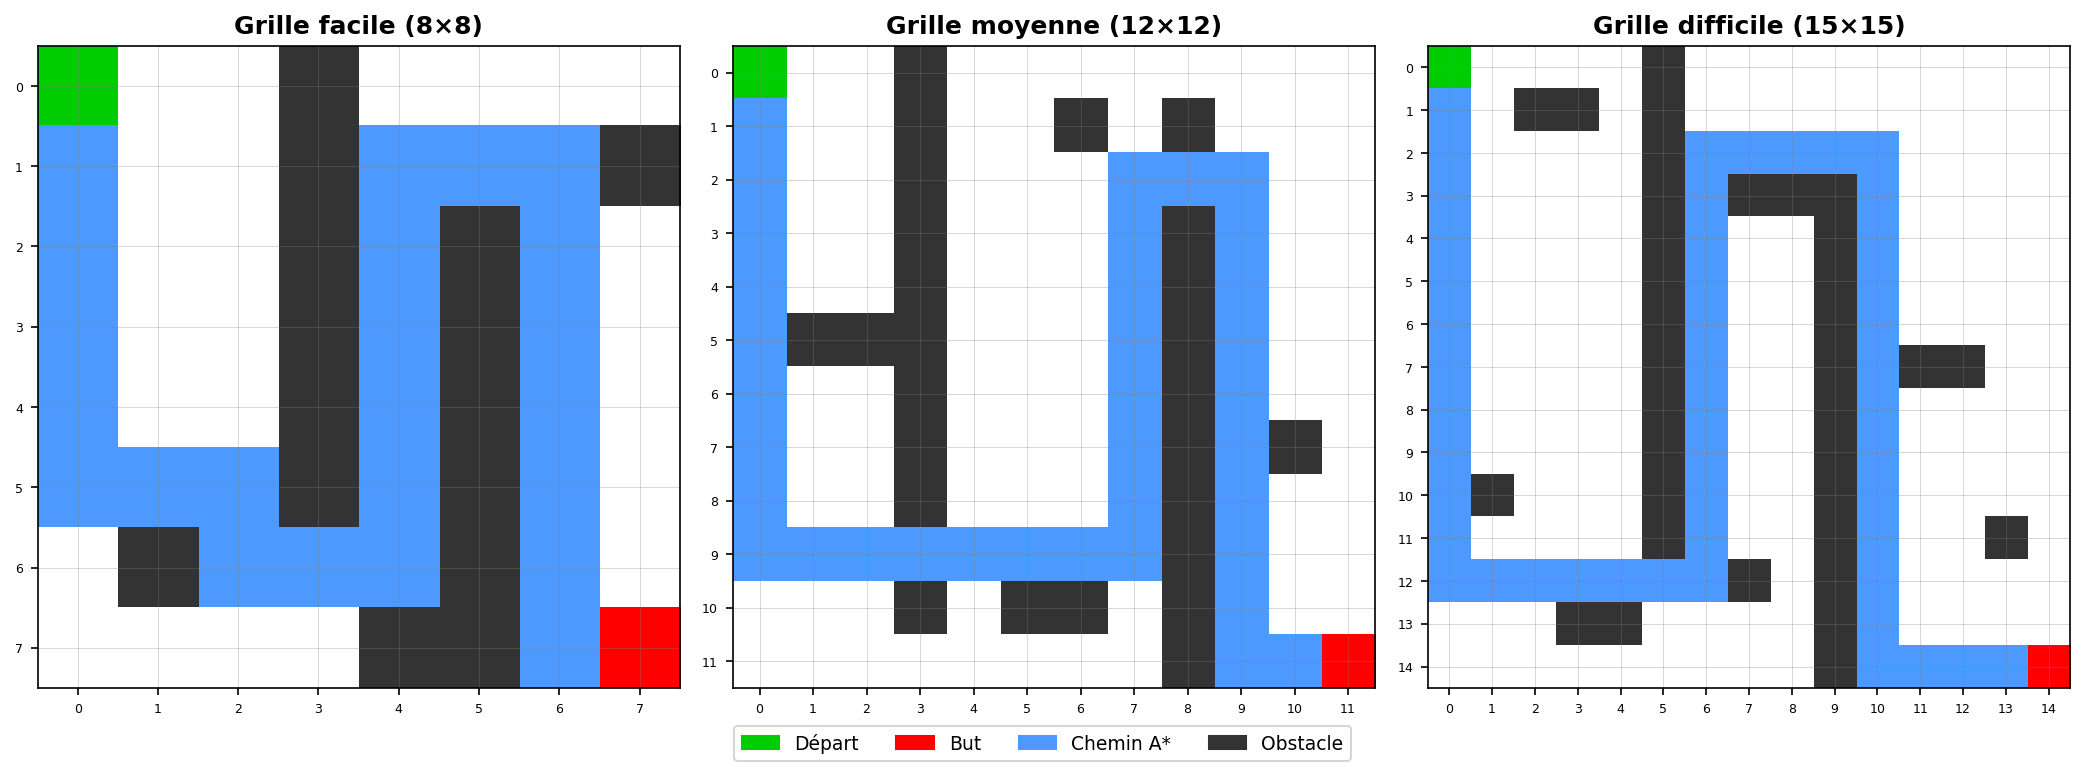

Figure sauvegardée : fig_grilles.png


In [14]:
def plot_grille(ax, grid, start, goal, path=None, title=""):
    rows, cols = grid.shape
    display = np.zeros((rows, cols, 3))
    for r in range(rows):
        for c in range(cols):
            if grid[r, c] == 1:
                display[r, c] = [0.2, 0.2, 0.2]
            else:
                display[r, c] = [1.0, 1.0, 1.0]

    if path:
        for r, c in path:
            display[r, c] = [0.3, 0.6, 1.0]

    display[start[0], start[1]] = [0.0, 0.8, 0.0]
    display[goal[0], goal[1]] = [1.0, 0.0, 0.0]

    ax.imshow(display, origin="upper")
    ax.set_title(title, fontweight="bold")
    ax.set_xticks(range(cols))
    ax.set_yticks(range(rows))
    ax.grid(True, linewidth=0.3, color="gray", alpha=0.5)
    ax.tick_params(labelsize=6)

grilles = get_grilles()
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for idx, (nom, (grid, start, goal)) in enumerate(grilles.items()):
    path, *_ = astar(grid, start, goal)
    plot_grille(axes[idx], grid, start, goal, path,
                f"Grille {nom} ({grid.shape[0]}×{grid.shape[1]})")

legend_elements = [
    mpatches.Patch(color=[0.0, 0.8, 0.0], label="Départ"),
    mpatches.Patch(color=[1.0, 0.0, 0.0], label="But"),
    mpatches.Patch(color=[0.3, 0.6, 1.0], label="Chemin A*"),
    mpatches.Patch(color=[0.2, 0.2, 0.2], label="Obstacle"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=4, fontsize=9)
plt.tight_layout(rect=[0, 0.06, 1, 1])
fig.savefig(os.path.join(RESULTS, "fig_grilles.png"), bbox_inches="tight")
plt.show()
print("Figure sauvegardée : fig_grilles.png")

---
## Expérience E.1 : Comparaison UCS vs Greedy vs $A^*$

On compare trois algorithmes de recherche sur les trois grilles en termes de :
- **Coût du chemin** (optimalité)
- **Nœuds développés** (efficacité de l'exploration)
- **Temps d'exécution**
- **Taille maximale de OPEN** (mémoire)

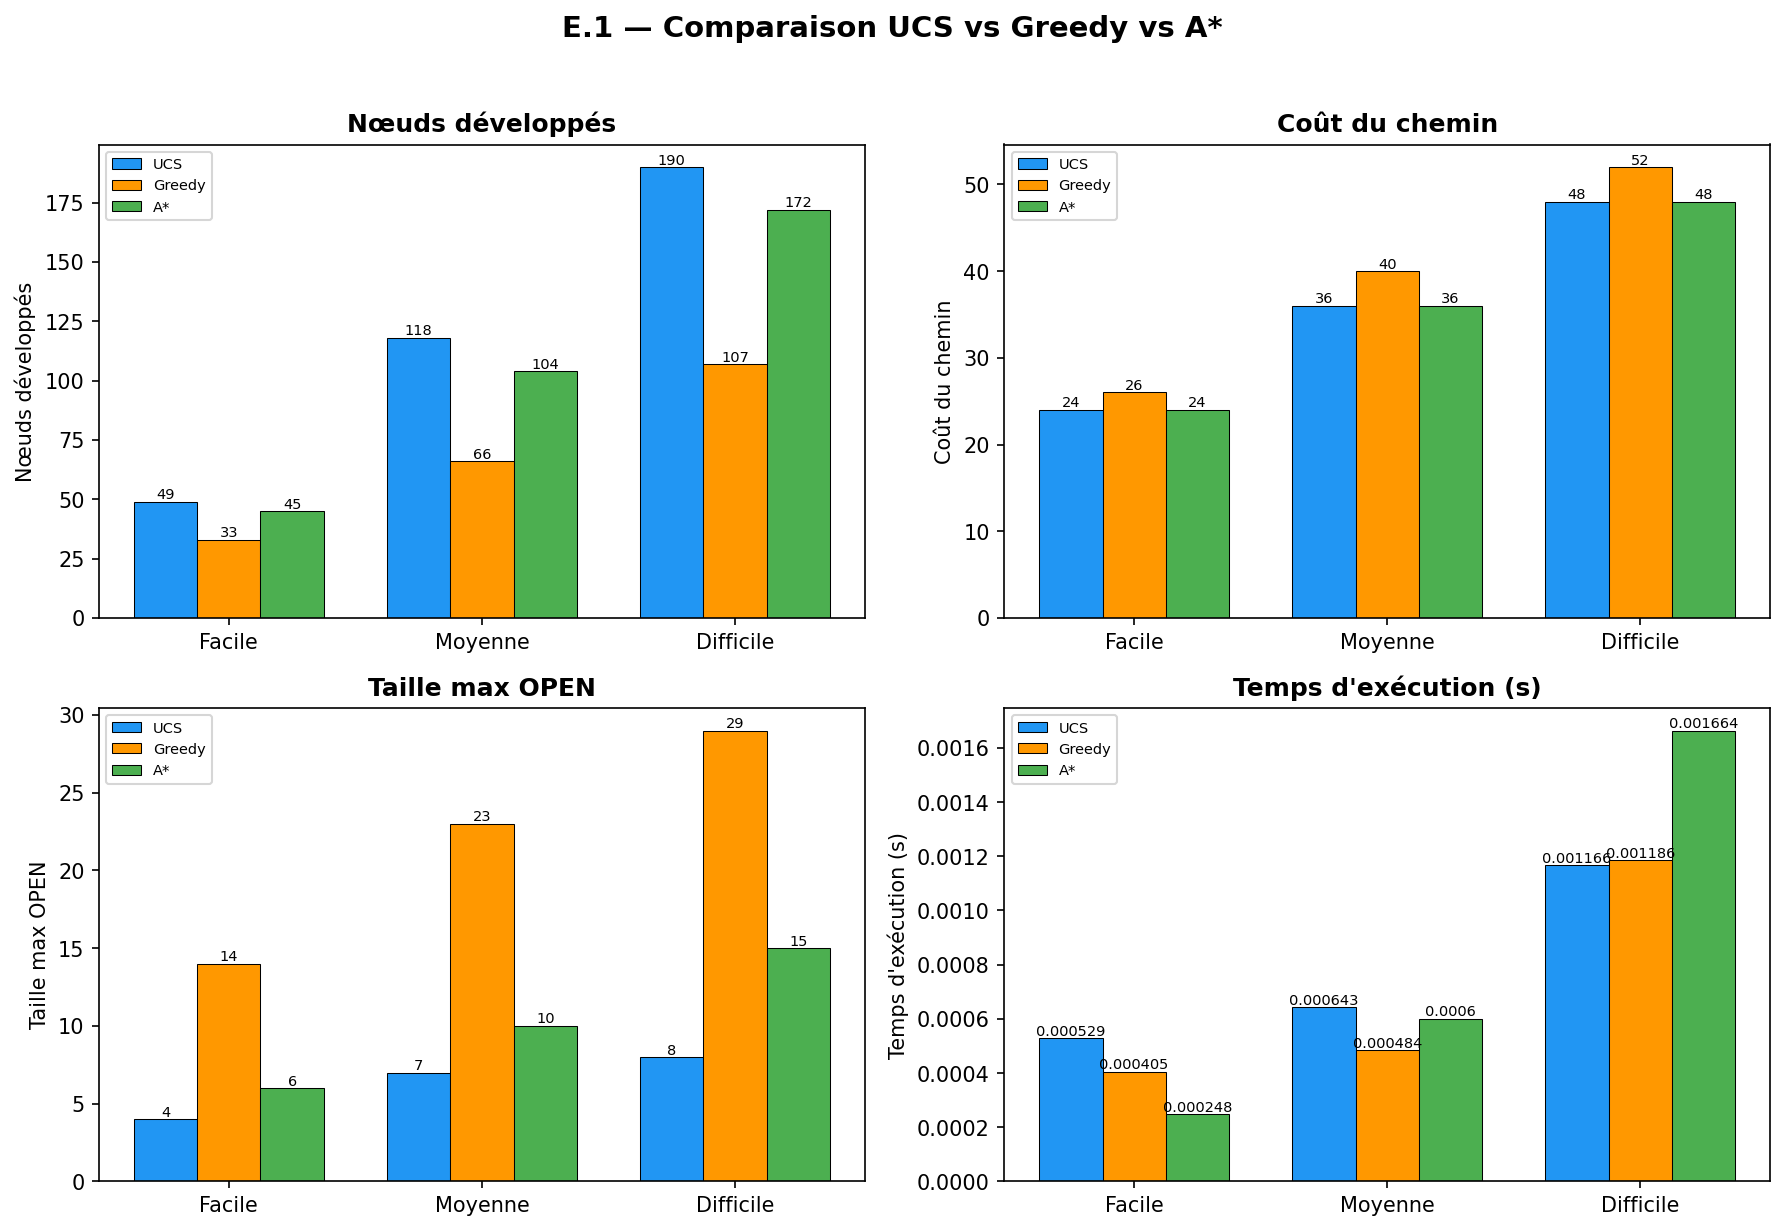

Figure sauvegardée : fig_E1_comparaison.png


In [15]:
e1 = load_json("E1_comparaison_algos.json")

noms_grilles = list(e1.keys())
algos = ["UCS", "Greedy", "A*"]
colors_algo = {"UCS": "#2196F3", "Greedy": "#FF9800", "A*": "#4CAF50"}

metrics = [
    ("noeuds_developpes", "Nœuds développés"),
    ("cout", "Coût du chemin"),
    ("taille_max_open", "Taille max OPEN"),
    ("temps_s", "Temps d'exécution (s)"),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

x = np.arange(len(noms_grilles))
width = 0.25

for ax_idx, (metric, label) in enumerate(metrics):
    ax = axes[ax_idx]
    for i, algo in enumerate(algos):
        vals = [e1[g][algo][metric] for g in noms_grilles]
        bars = ax.bar(x + i * width, vals, width, label=algo, color=colors_algo[algo], edgecolor="black", linewidth=0.5)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                    f"{v}", ha="center", va="bottom", fontsize=7)
    ax.set_xticks(x + width)
    ax.set_xticklabels([g.capitalize() for g in noms_grilles])
    ax.set_ylabel(label)
    ax.set_title(label, fontweight="bold")
    ax.legend(fontsize=7)

fig.suptitle("E.1 — Comparaison UCS vs Greedy vs A*", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(RESULTS, "fig_E1_comparaison.png"), bbox_inches="tight")
plt.show()
print("Figure sauvegardée : fig_E1_comparaison.png")

### Chemins trouvés par UCS, Greedy et $A^*$

Visualisation directe des chemins sur chaque grille pour comparer qualitativement les trois algorithmes.

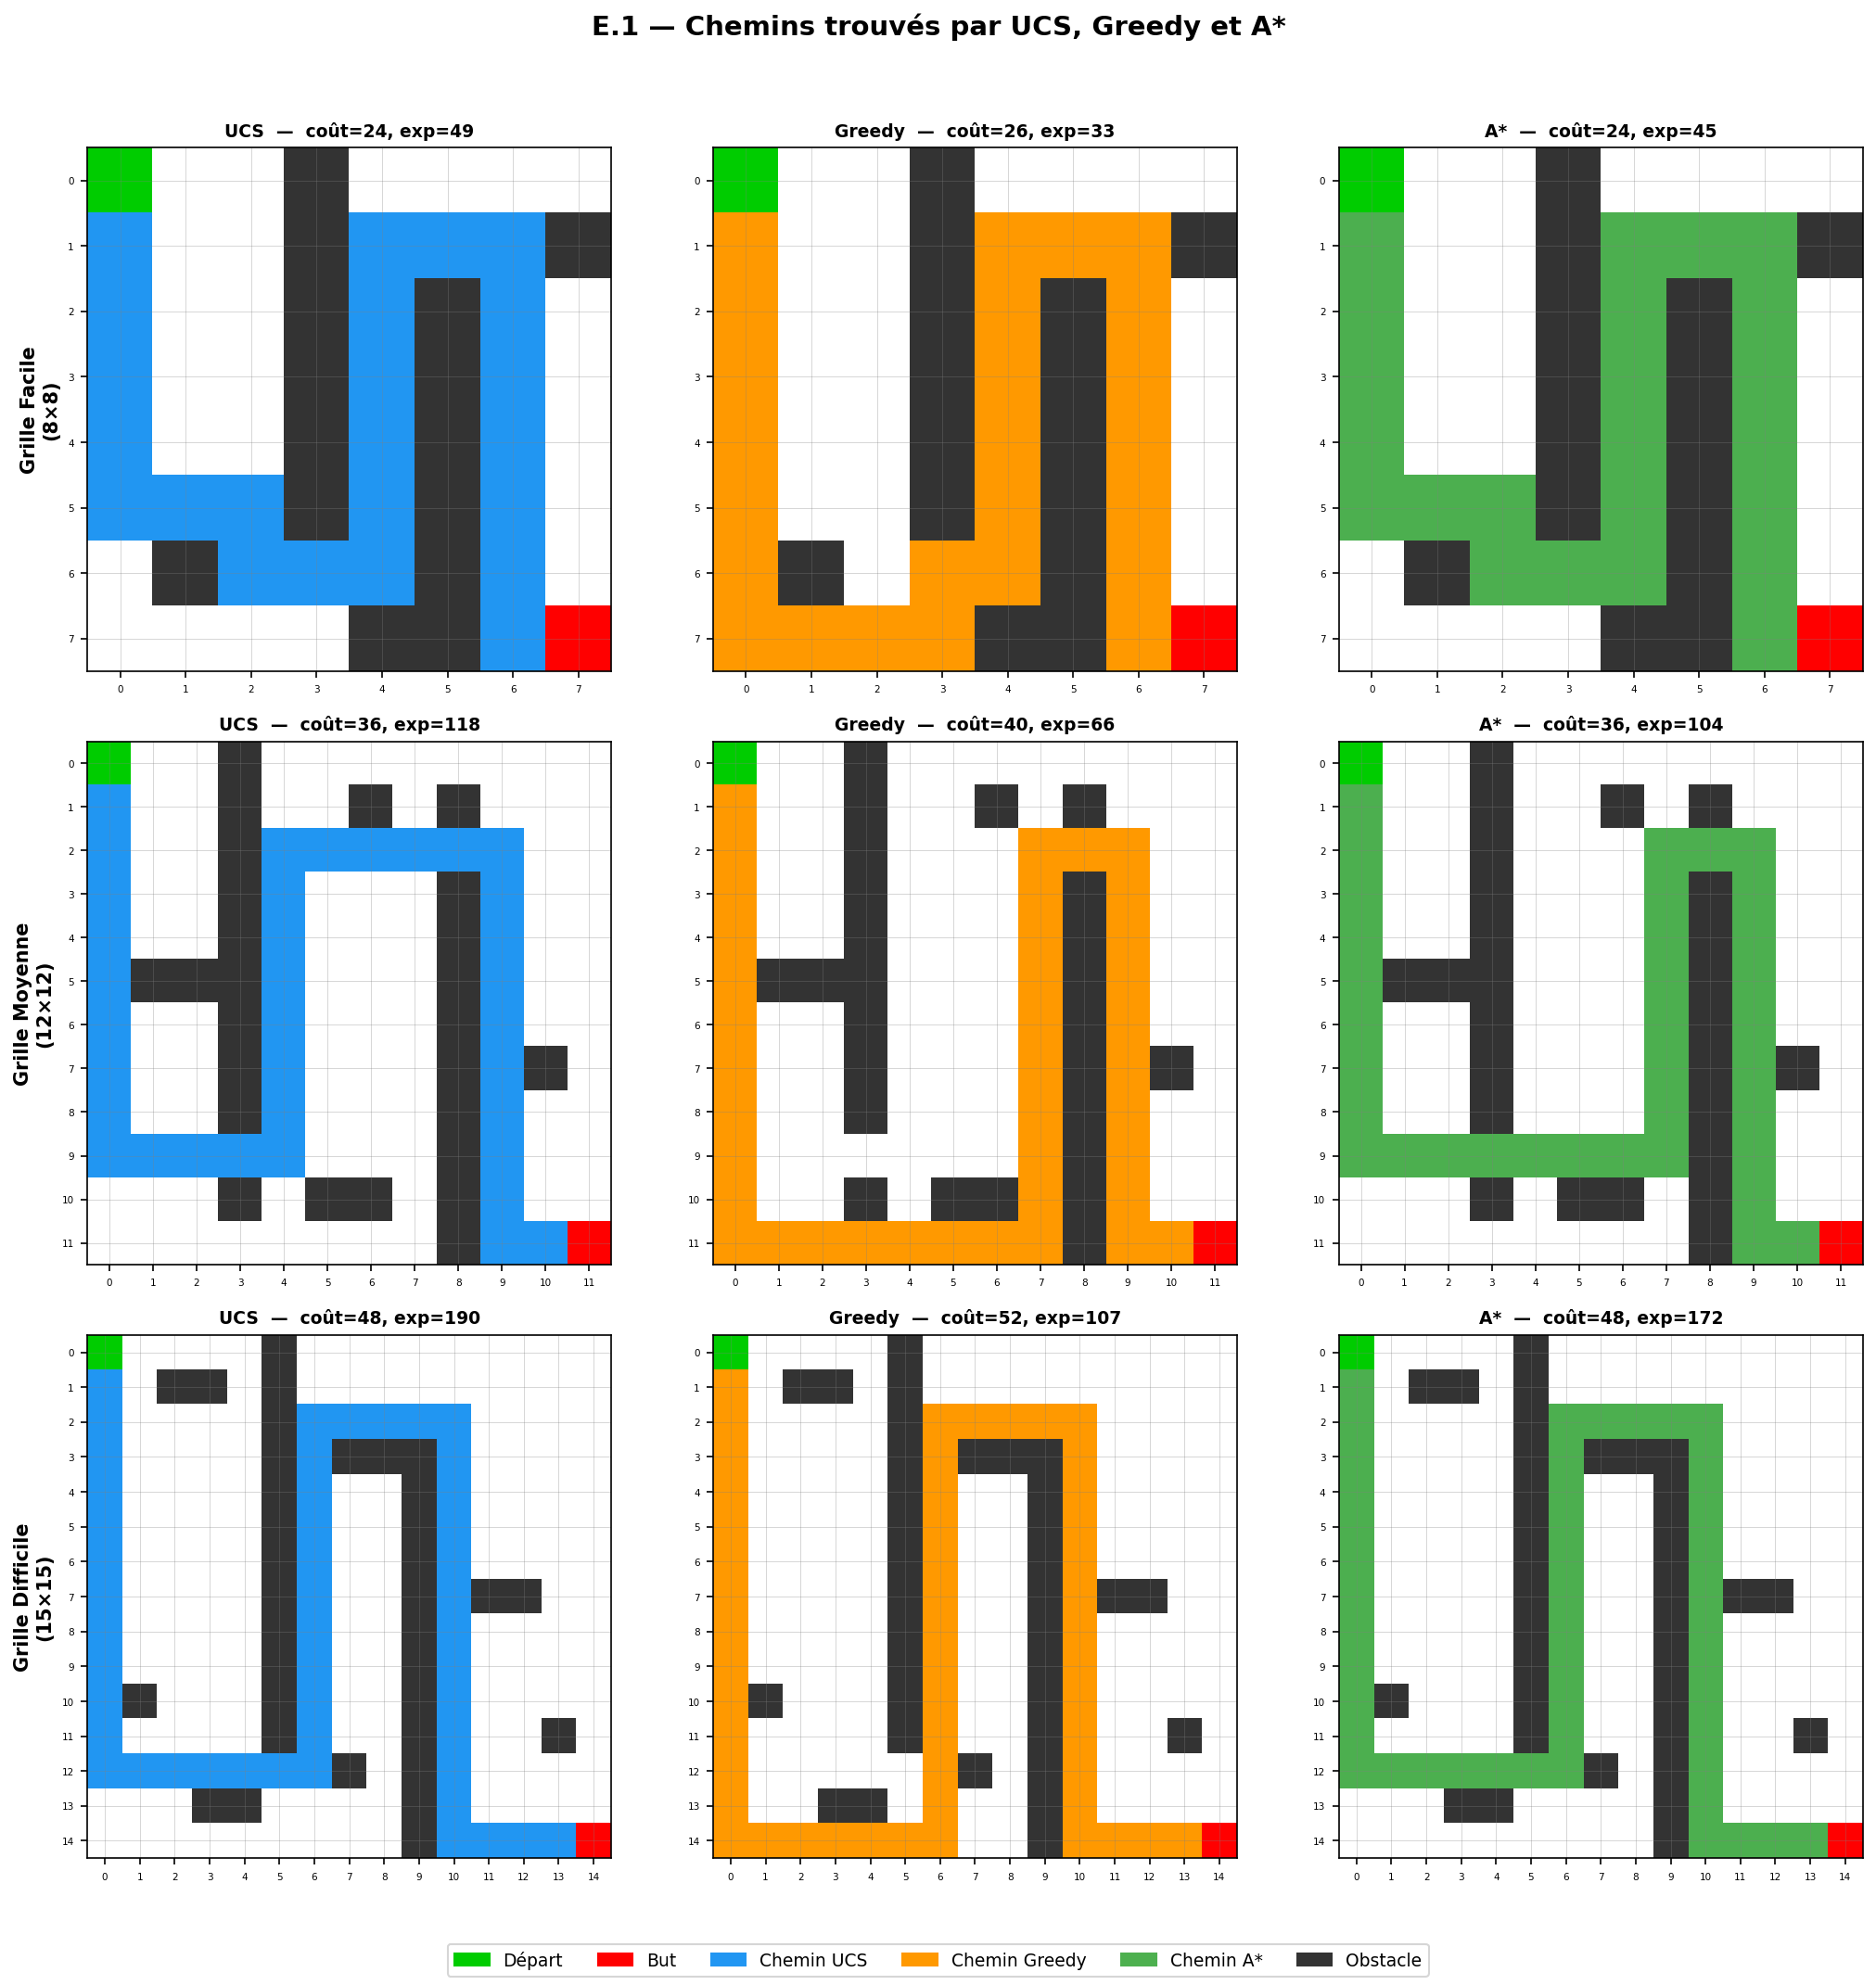

Figure sauvegardée : fig_E1_chemins.png


In [23]:
# --- Chemins trouvés par UCS, Greedy et A* sur les 3 grilles ---
algo_funcs = {"UCS": ucs, "Greedy": greedy, "A*": astar}
algo_colors = {"UCS": [0.13, 0.59, 0.95],      # bleu
               "Greedy": [1.0, 0.60, 0.0],      # orange
               "A*": [0.30, 0.69, 0.31]}        # vert

noms = ["facile", "moyenne", "difficile"]
fig, axes = plt.subplots(3, 3, figsize=(14, 14))

for row, nom in enumerate(noms):
    grid, start, goal = grilles[nom]
    rows, cols = grid.shape
    for col, (algo_name, algo_fn) in enumerate(algo_funcs.items()):
        ax = axes[row, col]
        path, cout, n_exp, *_ = algo_fn(grid, start, goal)

        # image de base : blanc=libre, gris foncé=obstacle
        display = np.zeros((rows, cols, 3))
        for r in range(rows):
            for c in range(cols):
                display[r, c] = [0.2, 0.2, 0.2] if grid[r, c] == 1 else [1.0, 1.0, 1.0]

        # colorier le chemin
        if path:
            for r, c in path:
                display[r, c] = algo_colors[algo_name]

        # départ et but par-dessus
        display[start[0], start[1]] = [0.0, 0.8, 0.0]
        display[goal[0], goal[1]] = [1.0, 0.0, 0.0]

        ax.imshow(display, origin="upper")
        ax.set_title(f"{algo_name}  —  coût={cout}, exp={n_exp}",
                     fontsize=9, fontweight="bold")
        ax.set_xticks(range(cols))
        ax.set_yticks(range(rows))
        ax.grid(True, linewidth=0.3, color="gray", alpha=0.5)
        ax.tick_params(labelsize=5)

        # étiquette de ligne (nom de la grille) sur la première colonne
        if col == 0:
            ax.set_ylabel(f"Grille {nom.capitalize()}\n({rows}×{cols})",
                          fontsize=10, fontweight="bold")

legend_elements = [
    mpatches.Patch(color=[0.0, 0.8, 0.0], label="Départ"),
    mpatches.Patch(color=[1.0, 0.0, 0.0], label="But"),
    mpatches.Patch(color=algo_colors["UCS"], label="Chemin UCS"),
    mpatches.Patch(color=algo_colors["Greedy"], label="Chemin Greedy"),
    mpatches.Patch(color=algo_colors["A*"], label="Chemin A*"),
    mpatches.Patch(color=[0.2, 0.2, 0.2], label="Obstacle"),
]

fig.suptitle("E.1 — Chemins trouvés par UCS, Greedy et A*",
             fontsize=14, fontweight="bold", y=1.01)
fig.legend(handles=legend_elements, loc="lower center", ncol=6, fontsize=9)
plt.tight_layout(rect=[0, 0.04, 1, 0.99])
fig.savefig(os.path.join(RESULTS, "fig_E1_chemins.png"), bbox_inches="tight")
plt.show()
print("Figure sauvegardée : fig_E1_chemins.png")

---
## Expérience E.2 : Impact de l'incertitude $\varepsilon$ sur la robustesse

On fixe le chemin $A^*$ optimal et on varie le taux de déviation $\varepsilon \in \{0, 0.1, 0.2, 0.3\}$.

Pour chaque $\varepsilon$, on mesure :
1. La **probabilité d'absorption vers GOAL** (calcul matriciel exact via $N = (I-Q)^{-1}$)
2. La **probabilité empirique** (simulation Monte Carlo, $N=2000$ trajectoires)
3. L'**évolution temporelle** de $P(\text{GOAL})$ via $\pi^{(n)} = \pi^{(0)} P^n$

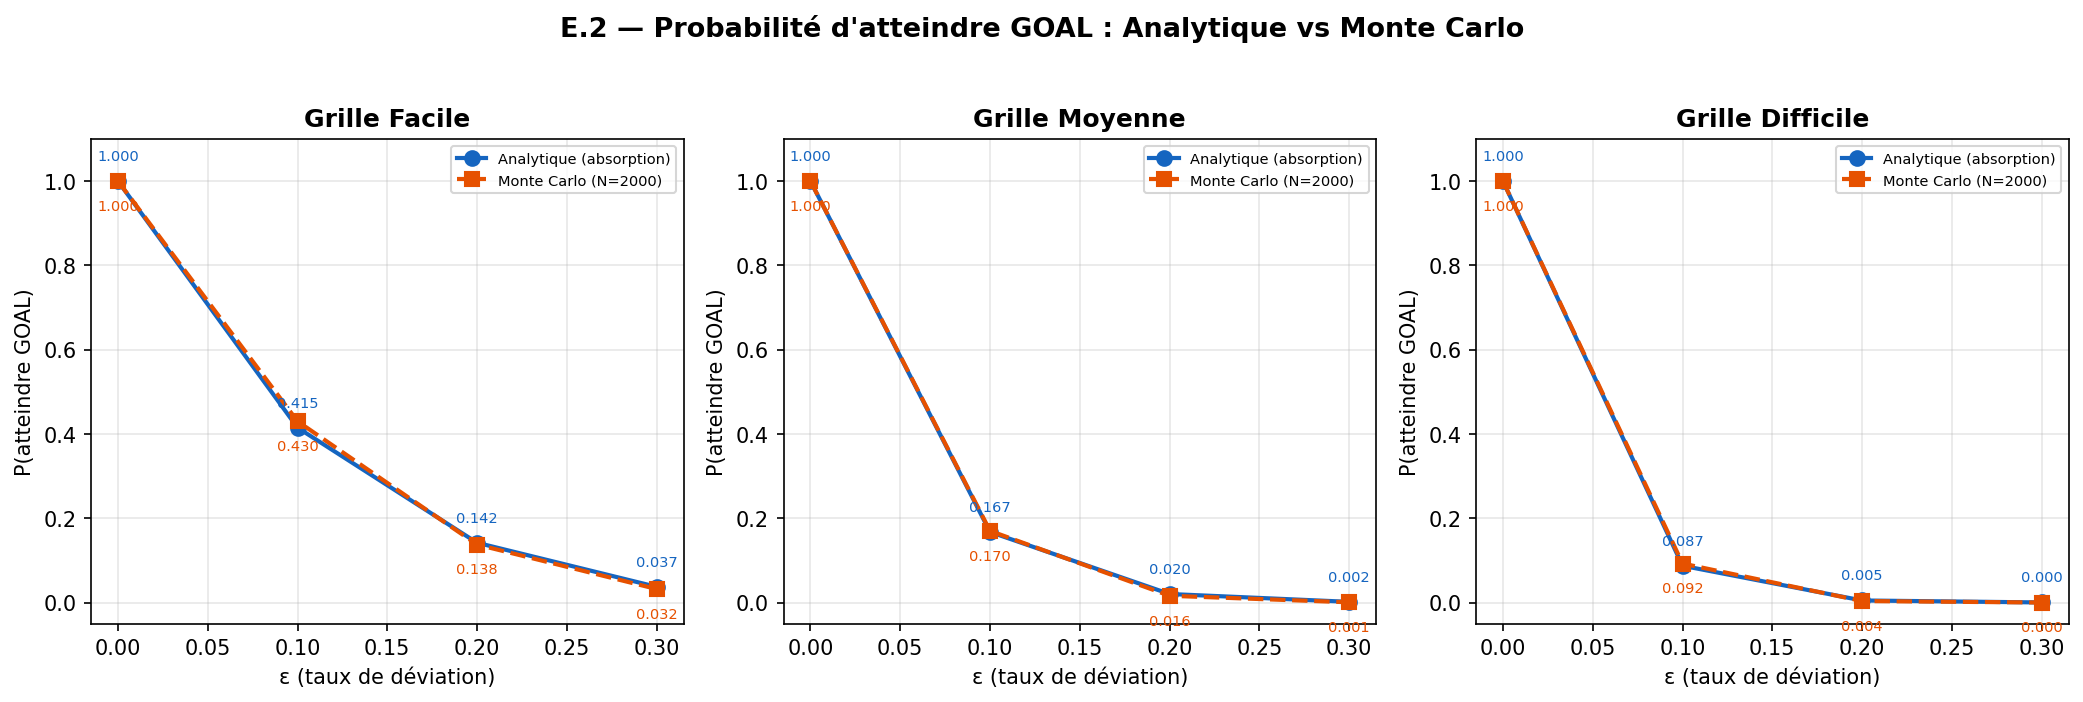

Figure sauvegardée : fig_E2_proba_goal.png


In [16]:
e2 = load_json("E2_impact_epsilon.json")

# --- Figure 1 : P(GOAL) analytique vs Monte Carlo ---
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

for idx, nom in enumerate(e2.keys()):
    ax = axes[idx]
    epsilons = sorted(e2[nom]["epsilons"].keys(), key=float)
    eps_vals = [float(e) for e in epsilons]
    p_abs = [e2[nom]["epsilons"][e]["proba_abs_goal"] for e in epsilons]
    p_mc = [e2[nom]["epsilons"][e]["mc_proba_succes"] for e in epsilons]

    ax.plot(eps_vals, p_abs, "o-", color="#1565C0", linewidth=2, markersize=7, label="Analytique (absorption)")
    ax.plot(eps_vals, p_mc, "s--", color="#E65100", linewidth=2, markersize=7, label="Monte Carlo (N=2000)")

    for i, (pa, pm) in enumerate(zip(p_abs, p_mc)):
        ax.annotate(f"{pa:.3f}", (eps_vals[i], pa), textcoords="offset points",
                    xytext=(0, 10), fontsize=7, ha="center", color="#1565C0")
        ax.annotate(f"{pm:.3f}", (eps_vals[i], pm), textcoords="offset points",
                    xytext=(0, -14), fontsize=7, ha="center", color="#E65100")

    ax.set_xlabel("ε (taux de déviation)")
    ax.set_ylabel("P(atteindre GOAL)")
    ax.set_title(f"Grille {nom.capitalize()}", fontweight="bold")
    ax.set_ylim(-0.05, 1.1)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

fig.suptitle("E.2 — Probabilité d'atteindre GOAL : Analytique vs Monte Carlo",
             fontsize=13, fontweight="bold", y=1.03)
plt.tight_layout()
fig.savefig(os.path.join(RESULTS, "fig_E2_proba_goal.png"), bbox_inches="tight")
plt.show()
print("Figure sauvegardée : fig_E2_proba_goal.png")

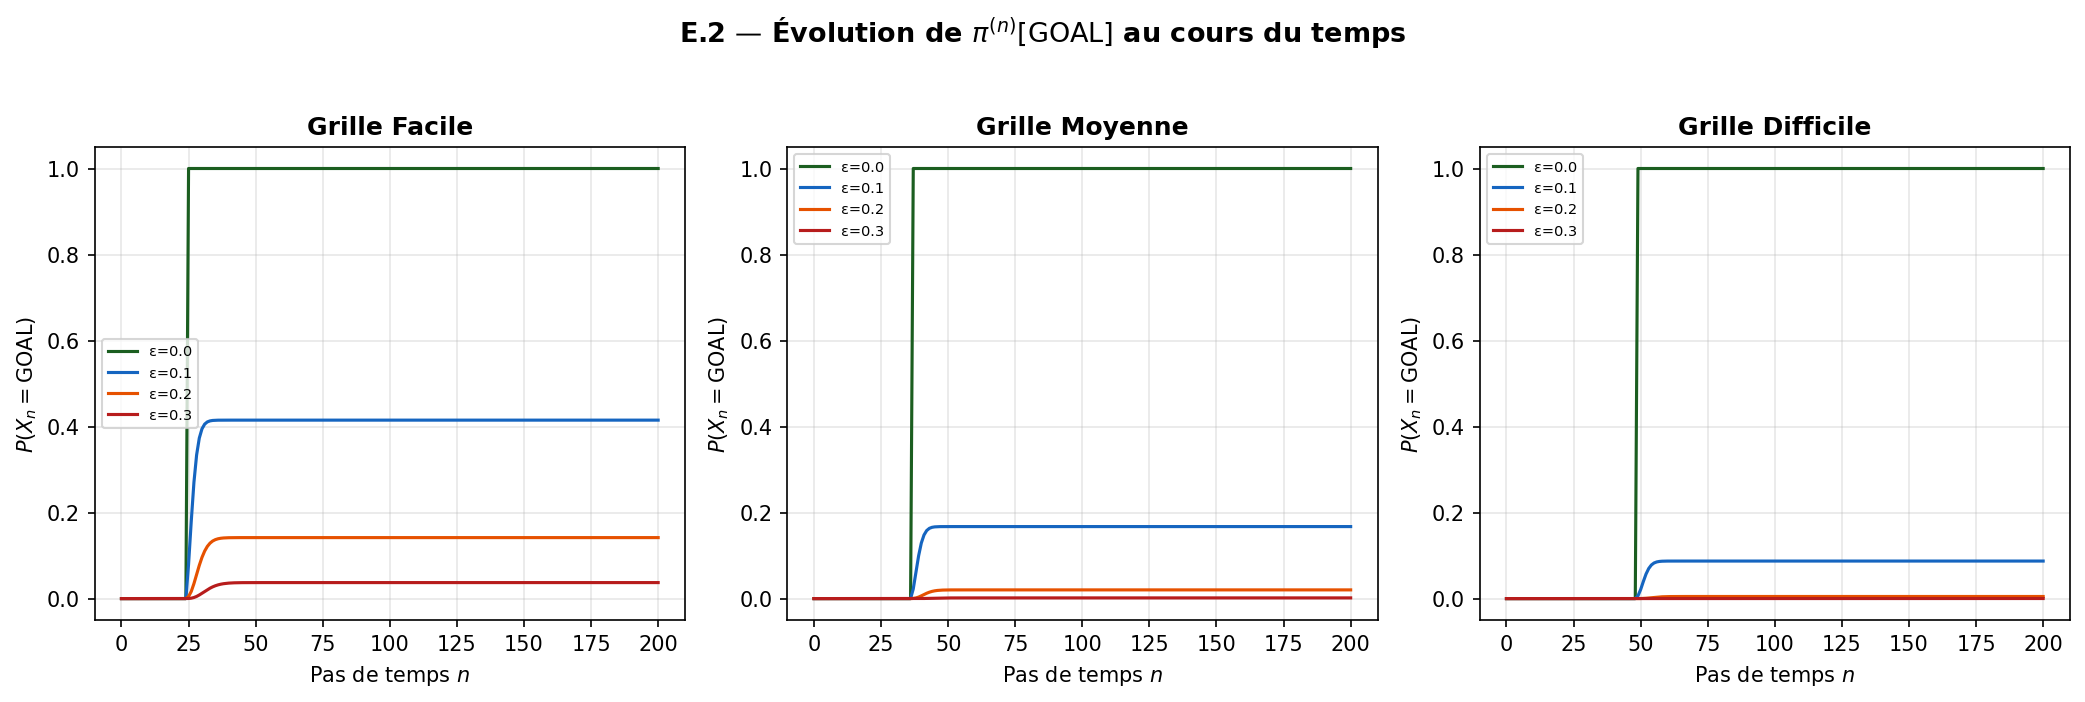

Figure sauvegardée : fig_E2_evolution_temporelle.png


In [17]:
# --- Figure 2 : Évolution temporelle de P(GOAL) = pi^(n)[GOAL] ---
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
cmap_eps = {0.0: "#1B5E20", 0.1: "#1565C0", 0.2: "#E65100", 0.3: "#B71C1C"}

for idx, nom in enumerate(e2.keys()):
    ax = axes[idx]
    epsilons = sorted(e2[nom]["epsilons"].keys(), key=float)

    for eps_str in epsilons:
        eps = float(eps_str)
        curve = e2[nom]["epsilons"][eps_str]["proba_goal_curve"]
        steps = list(range(len(curve)))
        ax.plot(steps, curve, linewidth=1.5, color=cmap_eps[eps], label=f"ε={eps}")

    ax.set_xlabel("Pas de temps $n$")
    ax.set_ylabel("$P(X_n = \\mathrm{GOAL})$")
    ax.set_title(f"Grille {nom.capitalize()}", fontweight="bold")
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

fig.suptitle("E.2 — Évolution de $\\pi^{(n)}[\\mathrm{GOAL}]$ au cours du temps",
             fontsize=13, fontweight="bold", y=1.03)
plt.tight_layout()
fig.savefig(os.path.join(RESULTS, "fig_E2_evolution_temporelle.png"), bbox_inches="tight")
plt.show()
print("Figure sauvegardée : fig_E2_evolution_temporelle.png")

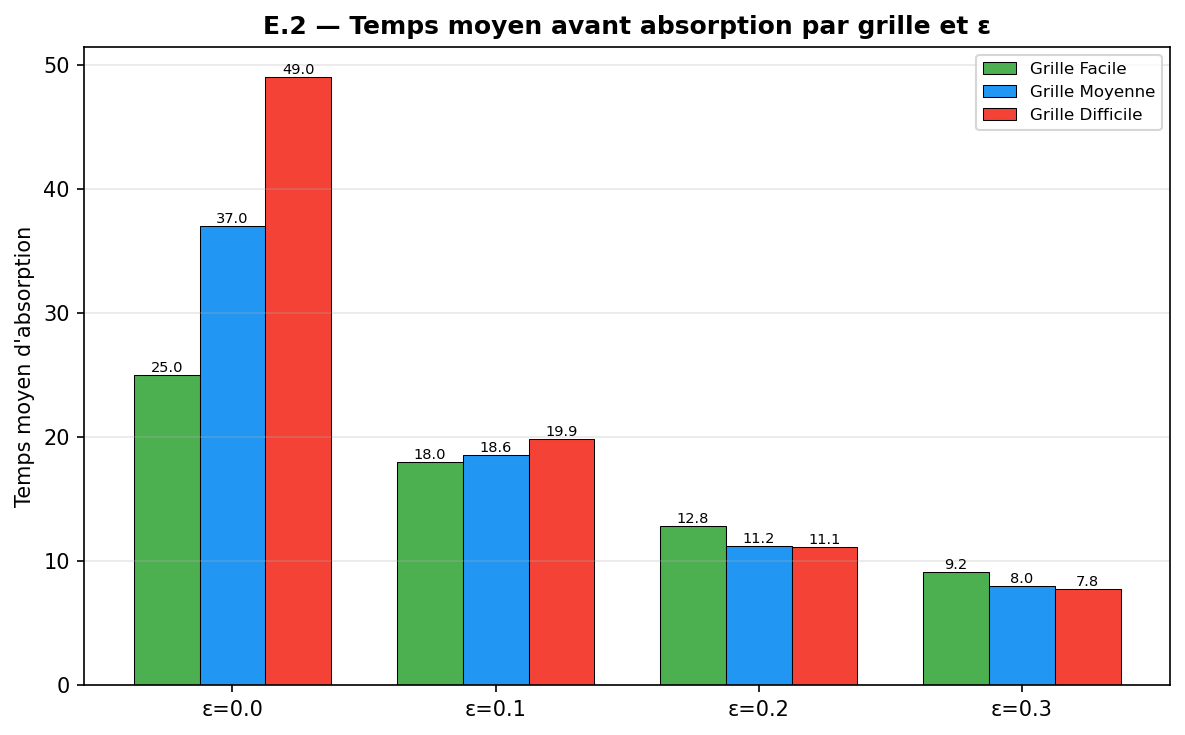

Figure sauvegardée : fig_E2_temps_absorption.png


In [18]:
# --- Figure 3 : Temps moyen d'absorption ---
fig, ax = plt.subplots(figsize=(8, 5))

noms = list(e2.keys())
epsilons = sorted(e2[noms[0]]["epsilons"].keys(), key=float)
x = np.arange(len(epsilons))
width = 0.25
colors_grille = {"facile": "#4CAF50", "moyenne": "#2196F3", "difficile": "#F44336"}

for i, nom in enumerate(noms):
    temps = [e2[nom]["epsilons"][e]["temps_moyen_absorption"] for e in epsilons]
    bars = ax.bar(x + i * width, temps, width, label=f"Grille {nom.capitalize()}",
                  color=colors_grille[nom], edgecolor="black", linewidth=0.5)
    for bar, t in zip(bars, temps):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f"{t:.1f}", ha="center", va="bottom", fontsize=7)

ax.set_xticks(x + width)
ax.set_xticklabels([f"ε={e}" for e in epsilons])
ax.set_ylabel("Temps moyen d'absorption")
ax.set_title("E.2 — Temps moyen avant absorption par grille et ε", fontweight="bold")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
fig.savefig(os.path.join(RESULTS, "fig_E2_temps_absorption.png"), bbox_inches="tight")
plt.show()
print("Figure sauvegardée : fig_E2_temps_absorption.png")

---
## Expérience E.3 : Comparaison de deux heuristiques admissibles

On compare $A^*$ avec $h=0$ (équivalent à UCS) et $h = \text{Manhattan}$.
Les deux sont admissibles, mais Manhattan **domine** $h=0$ ($h_{\text{Man}} \geq h_0$ partout), donc elle doit réduire le nombre de nœuds développés tout en garantissant l'optimalité.

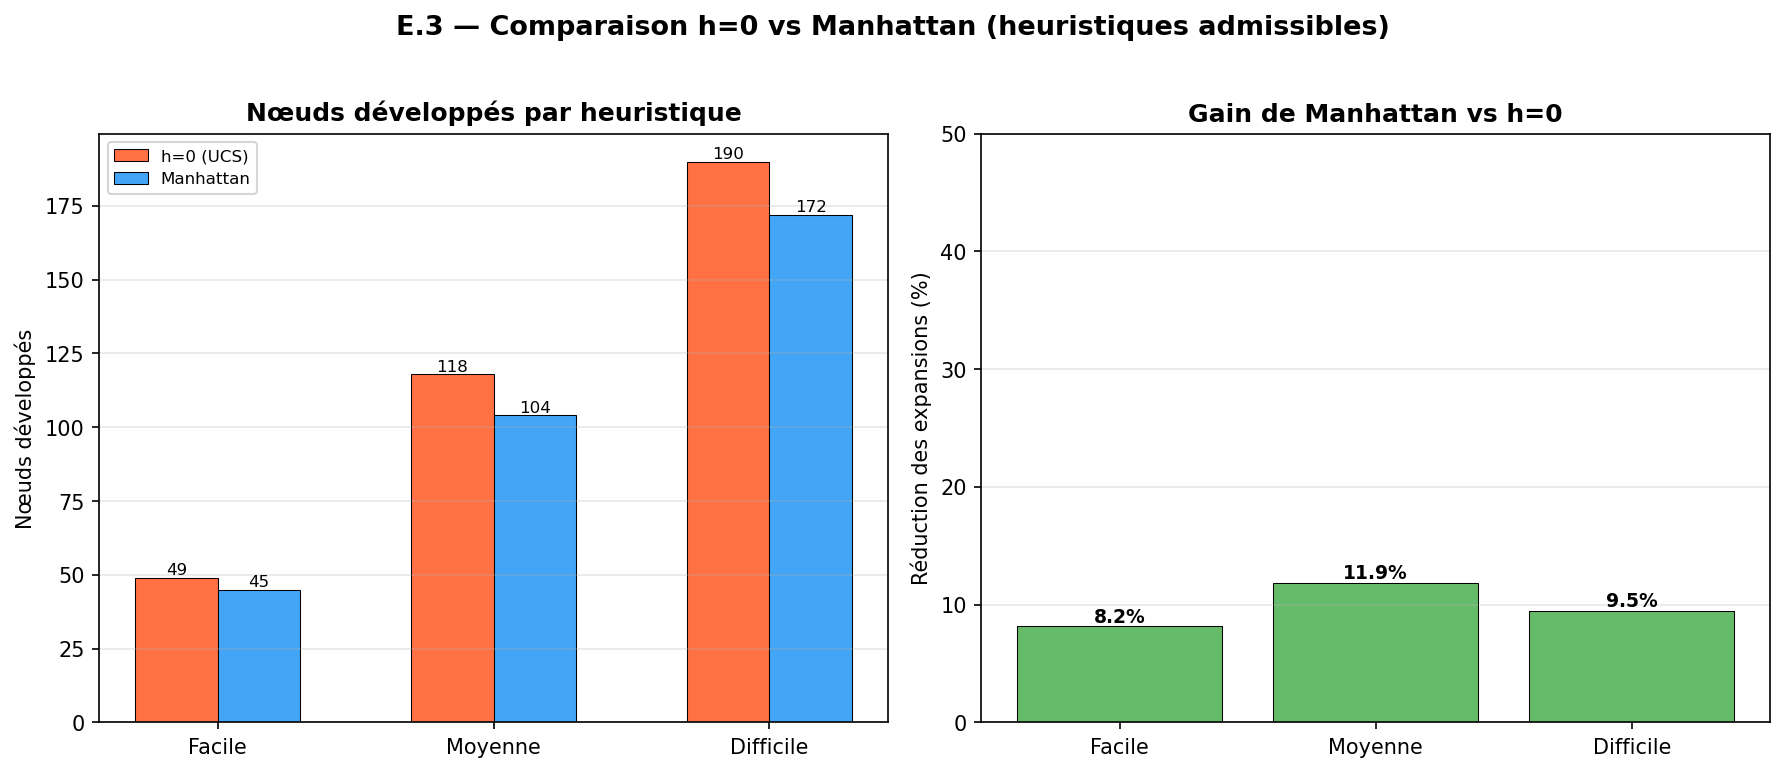

Figure sauvegardée : fig_E3_heuristiques.png


In [19]:
e3 = load_json("E3_heuristiques.json")

noms = list(e3.keys())
h_names = list(e3[noms[0]].keys())
colors_h = {"h=0 (UCS)": "#FF7043", "Manhattan": "#42A5F5"}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Nœuds développés
ax = axes[0]
x = np.arange(len(noms))
width = 0.3
for i, h in enumerate(h_names):
    vals = [e3[g][h]["noeuds_developpes"] for g in noms]
    bars = ax.bar(x + i * width, vals, width, label=h, color=colors_h[h],
                  edgecolor="black", linewidth=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                str(v), ha="center", va="bottom", fontsize=8)
ax.set_xticks(x + width / 2)
ax.set_xticklabels([g.capitalize() for g in noms])
ax.set_ylabel("Nœuds développés")
ax.set_title("Nœuds développés par heuristique", fontweight="bold")
ax.legend()
ax.grid(axis="y", alpha=0.3)

# Réduction en %
ax = axes[1]
for g in noms:
    n0 = e3[g]["h=0 (UCS)"]["noeuds_developpes"]
    nm = e3[g]["Manhattan"]["noeuds_developpes"]
    reduction = (1 - nm / n0) * 100
    bar = ax.bar(g.capitalize(), reduction, color="#66BB6A", edgecolor="black", linewidth=0.5)
    ax.text(bar[0].get_x() + bar[0].get_width()/2, bar[0].get_height(),
            f"{reduction:.1f}%", ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_ylabel("Réduction des expansions (%)")
ax.set_title("Gain de Manhattan vs h=0", fontweight="bold")
ax.set_ylim(0, max(50, ax.get_ylim()[1] * 1.2))
ax.grid(axis="y", alpha=0.3)

fig.suptitle("E.3 — Comparaison h=0 vs Manhattan (heuristiques admissibles)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(RESULTS, "fig_E3_heuristiques.png"), bbox_inches="tight")
plt.show()
print("Figure sauvegardée : fig_E3_heuristiques.png")

---
## Expérience E.4 : Weighted $A^*$ — Compromis Vitesse vs Optimalité

Weighted $A^*$ utilise $f(n) = g(n) + w \cdot h(n)$ avec $w \geq 1$.
- $w = 1$ : $A^*$ standard (optimal)
- $w > 1$ : plus rapide (moins d'expansions) mais solution potentiellement sous-optimale (coût $\leq w \cdot c^*$)

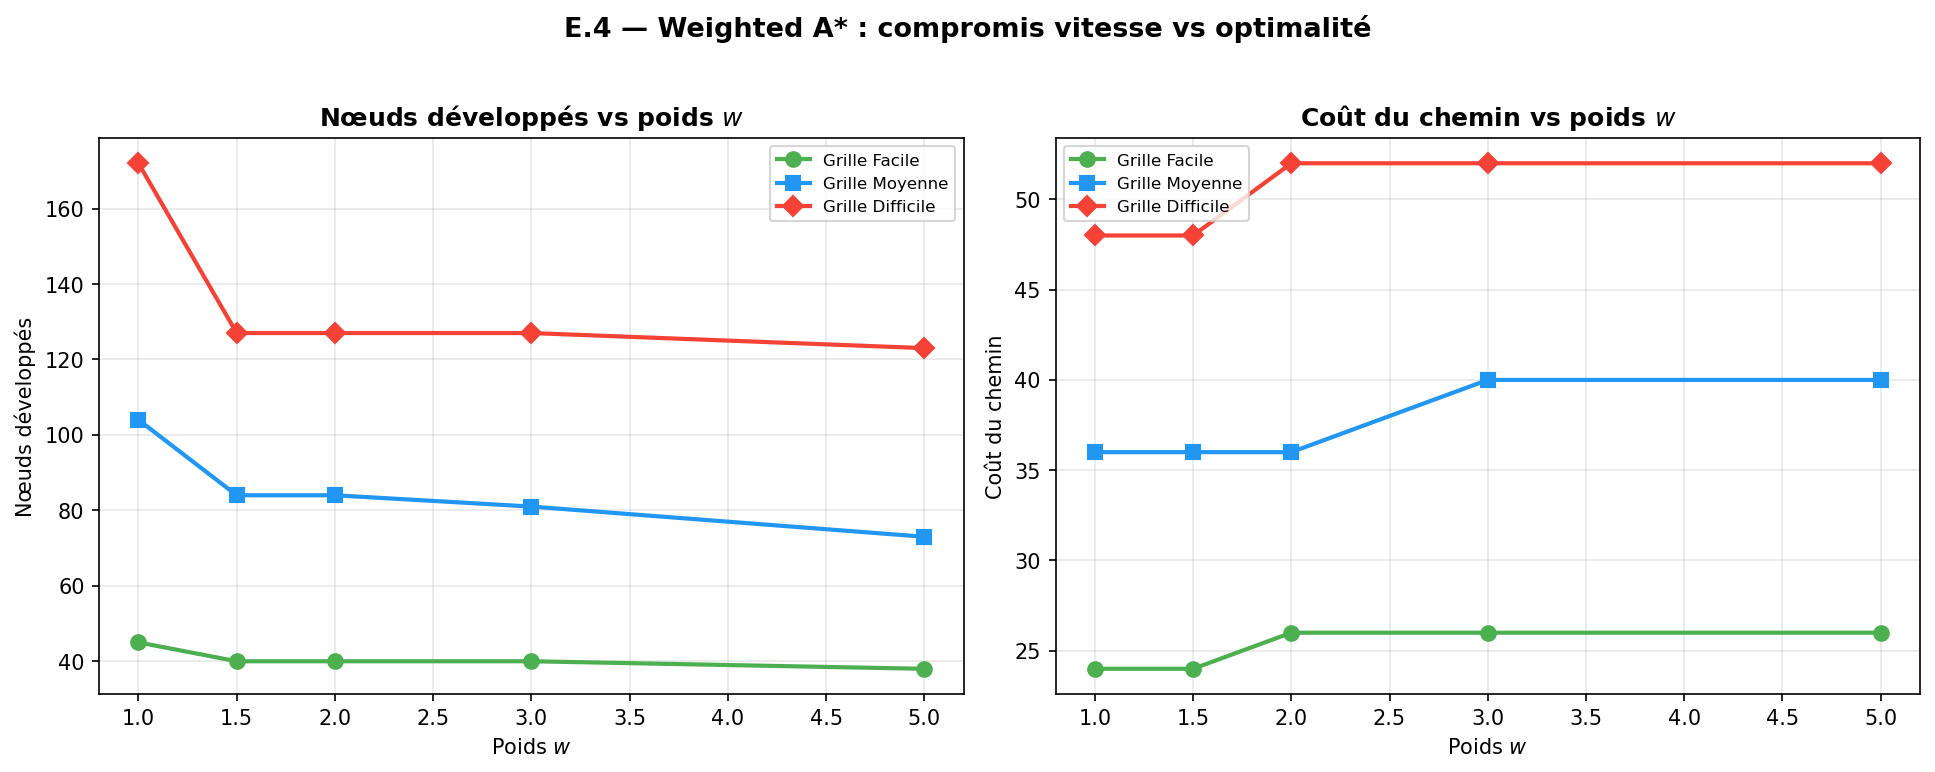

Figure sauvegardée : fig_E4_weighted_astar.png


In [20]:
e4 = load_json("E4_weighted_astar.json")

noms = list(e4.keys())
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors_grille = {"facile": "#4CAF50", "moyenne": "#2196F3", "difficile": "#F44336"}
markers = {"facile": "o", "moyenne": "s", "difficile": "D"}

# Nœuds développés vs w
ax = axes[0]
for nom in noms:
    weights = []
    expansions = []
    for key in e4[nom]:
        w = e4[nom][key]["poids"]
        weights.append(w)
        expansions.append(e4[nom][key]["noeuds_developpes"])
    ax.plot(weights, expansions, f"{markers[nom]}-", color=colors_grille[nom],
            linewidth=2, markersize=7, label=f"Grille {nom.capitalize()}")
ax.set_xlabel("Poids $w$")
ax.set_ylabel("Nœuds développés")
ax.set_title("Nœuds développés vs poids $w$", fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)

# Coût vs w
ax = axes[1]
for nom in noms:
    weights = []
    costs = []
    for key in e4[nom]:
        w = e4[nom][key]["poids"]
        weights.append(w)
        costs.append(e4[nom][key]["cout"])
    ax.plot(weights, costs, f"{markers[nom]}-", color=colors_grille[nom],
            linewidth=2, markersize=7, label=f"Grille {nom.capitalize()}")
ax.set_xlabel("Poids $w$")
ax.set_ylabel("Coût du chemin")
ax.set_title("Coût du chemin vs poids $w$", fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)

fig.suptitle("E.4 — Weighted A* : compromis vitesse vs optimalité",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(RESULTS, "fig_E4_weighted_astar.png"), bbox_inches="tight")
plt.show()
print("Figure sauvegardée : fig_E4_weighted_astar.png")

---
## Analyse Markov complémentaire : Simulation Monte Carlo

Visualisation de trajectoires simulées sur la grille difficile avec $\varepsilon = 0.2$, et distribution du temps d'atteinte.

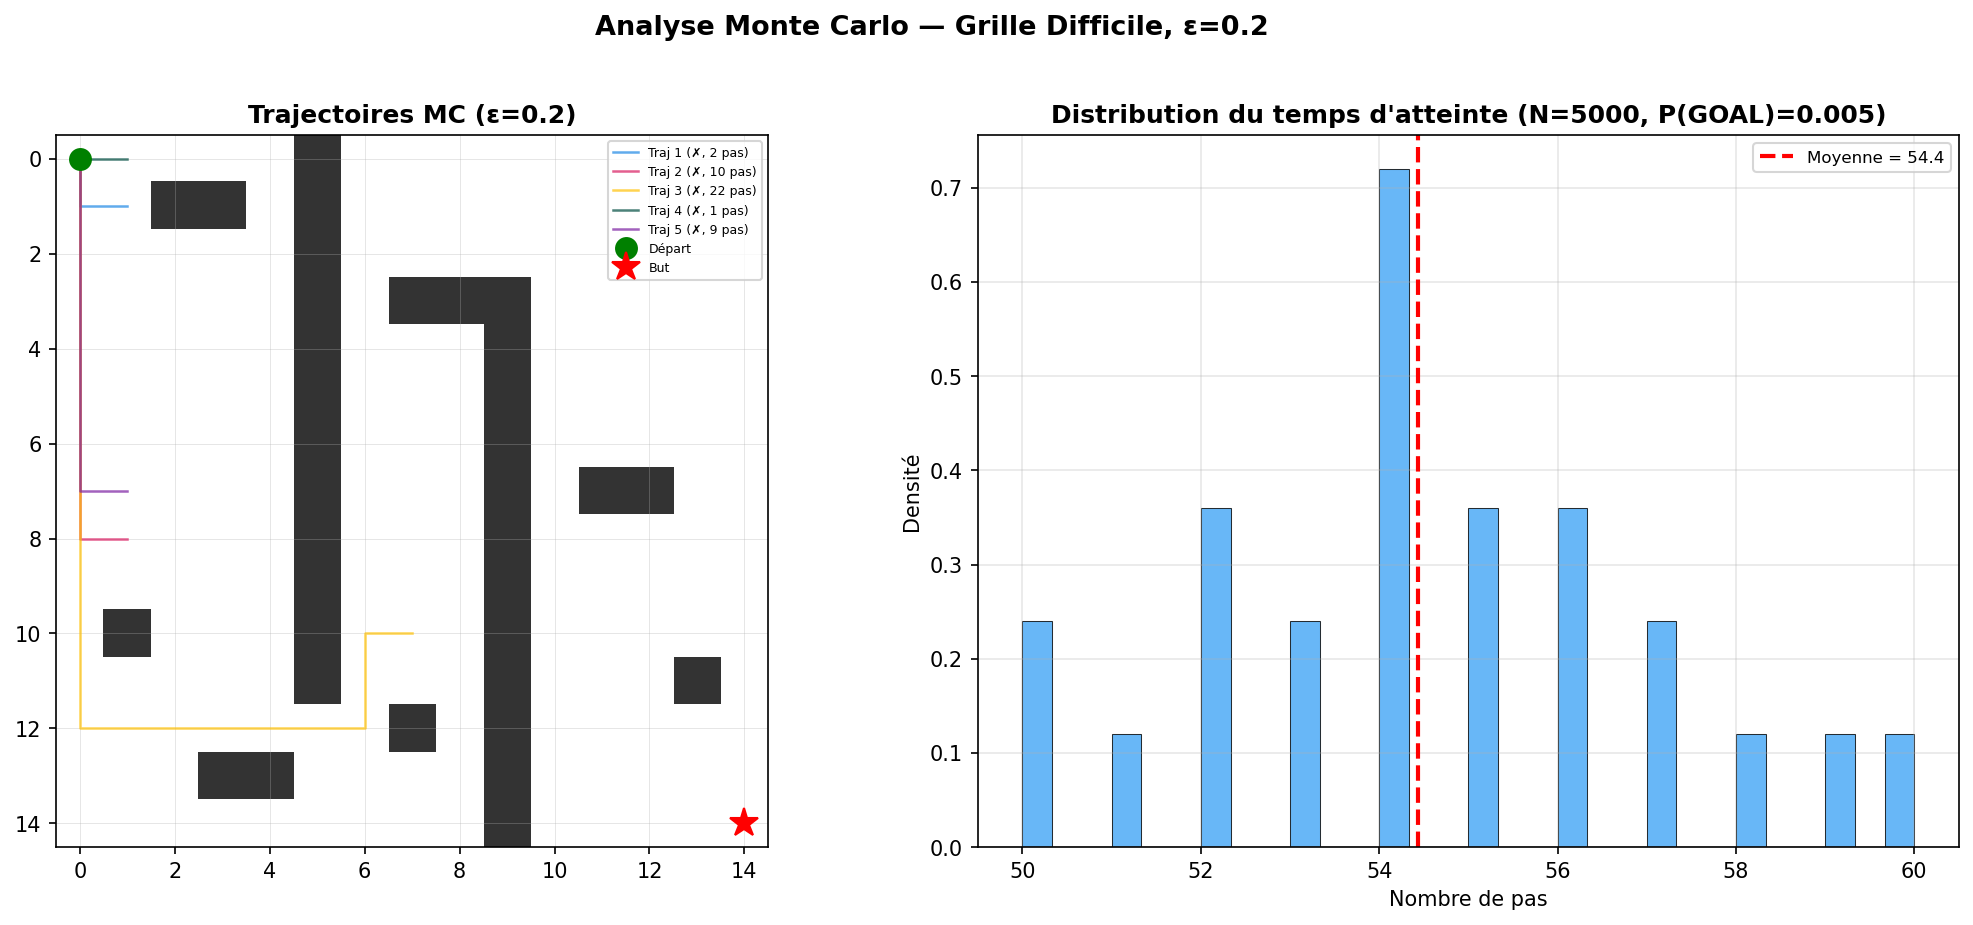

Figure sauvegardée : fig_monte_carlo_analyse.png


In [21]:
from src.markov import simulation_trajectoire

grid_diff, start_diff, goal_diff = grilles["difficile"]
path_diff, *_ = astar(grid_diff, start_diff, goal_diff)
pol_diff = construire_politique(grid_diff, path_diff)

np.random.seed(42)
eps_demo = 0.2
n_traj = 5

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Trajectoires simulées sur la grille
ax = axes[0]
rows, cols = grid_diff.shape
display = np.ones((rows, cols, 3))
for r in range(rows):
    for c in range(cols):
        if grid_diff[r, c] == 1:
            display[r, c] = [0.2, 0.2, 0.2]

ax.imshow(display, origin="upper")
colors_traj = ["#1E88E5", "#D81B60", "#FFC107", "#004D40", "#7B1FA2"]

for k in range(n_traj):
    ok, steps, traj = simulation_trajectoire(grid_diff, start_diff, goal_diff, pol_diff, eps_demo, max_steps=300)
    rs = [p[0] for p in traj]
    cs = [p[1] for p in traj]
    label = f"Traj {k+1} ({'✓' if ok else '✗'}, {steps} pas)"
    ax.plot(cs, rs, "-", color=colors_traj[k], alpha=0.7, linewidth=1.2, label=label)

ax.plot(start_diff[1], start_diff[0], "go", markersize=10, zorder=5, label="Départ")
ax.plot(goal_diff[1], goal_diff[0], "r*", markersize=14, zorder=5, label="But")
ax.set_title(f"Trajectoires MC (ε={eps_demo})", fontweight="bold")
ax.legend(fontsize=6, loc="upper right")
ax.grid(True, linewidth=0.3, alpha=0.5)

# Distribution du temps d'atteinte
ax = axes[1]
mc_results = simulation_monte_carlo(grid_diff, start_diff, goal_diff, pol_diff, eps_demo, n_sim=5000)

if mc_results["temps_atteinte"]:
    ax.hist(mc_results["temps_atteinte"], bins=30, color="#42A5F5", edgecolor="black",
            linewidth=0.5, alpha=0.8, density=True)
    ax.axvline(mc_results["temps_moyen"], color="red", linestyle="--", linewidth=2,
               label=f"Moyenne = {mc_results['temps_moyen']:.1f}")
    ax.set_xlabel("Nombre de pas")
    ax.set_ylabel("Densité")
    ax.legend()
else:
    ax.text(0.5, 0.5, "Aucune trajectoire\nn'atteint le but", ha="center", va="center",
            fontsize=12, transform=ax.transAxes)

ax.set_title(f"Distribution du temps d'atteinte (N={mc_results['n_sim']}, "
             f"P(GOAL)={mc_results['proba_succes']:.3f})", fontweight="bold")
ax.grid(True, alpha=0.3)

fig.suptitle("Analyse Monte Carlo — Grille Difficile, ε=0.2",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(RESULTS, "fig_monte_carlo_analyse.png"), bbox_inches="tight")
plt.show()
print("Figure sauvegardée : fig_monte_carlo_analyse.png")

---
## Tableau Récapitulatif E.2 : Impact de $\varepsilon$ sur la robustesse

In [22]:
# Tableau récapitulatif formaté
print("=" * 85)
print(f"{'Grille':<12} {'ε':<6} {'Coût A*':<10} {'P(GOAL) Ana.':<14} {'P(GOAL) MC':<13} {'T_moy abs.':<12}")
print("=" * 85)

for nom in e2.keys():
    cout = e2[nom]["cout_astar"]
    for eps_str in sorted(e2[nom]["epsilons"].keys(), key=float):
        d = e2[nom]["epsilons"][eps_str]
        print(f"{nom.capitalize():<12} {eps_str:<6} {cout:<10} "
              f"{d['proba_abs_goal']:<14.4f} {d['mc_proba_succes']:<13.4f} "
              f"{d['temps_moyen_absorption']:<12}")
    print("-" * 85)

print("\nConclusion : Plus ε augmente, plus la probabilité d'atteindre le but diminue.")
print("Les grilles complexes (difficile) sont beaucoup plus sensibles à l'incertitude.")

Grille       ε      Coût A*    P(GOAL) Ana.   P(GOAL) MC    T_moy abs.  
Facile       0.0    24         1.0000         1.0000        25.0        
Facile       0.1    24         0.4149         0.4300        17.99       
Facile       0.2    24         0.1418         0.1375        12.8        
Facile       0.3    24         0.0372         0.0320        9.17        
-------------------------------------------------------------------------------------
Moyenne      0.0    36         1.0000         1.0000        37.0        
Moyenne      0.1    36         0.1674         0.1700        18.58       
Moyenne      0.2    36         0.0202         0.0160        11.25       
Moyenne      0.3    36         0.0016         0.0005        8.02        
-------------------------------------------------------------------------------------
Difficile    0.0    48         1.0000         1.0000        49.0        
Difficile    0.1    48         0.0873         0.0925        19.85       
Difficile    0.2    48   

---
## Synthèse et Conclusions

### Résultats principaux

1. **E.1 — Comparaison des algorithmes** : $A^*$ avec Manhattan développe significativement moins de nœuds que UCS tout en garantissant l'optimalité. Greedy est le plus rapide mais ne garantit pas l'optimalité.

2. **E.2 — Impact de $\varepsilon$** : L'incertitude dégrade fortement la probabilité d'atteindre le but. Sur la grille difficile, $P(\text{GOAL})$ chute de $1.0$ (ε=0) à $< 0.01$ (ε=0.3). La concordance entre calcul analytique et Monte Carlo valide le modèle.

3. **E.3 — Dominance heuristique** : Manhattan domine $h=0$ au sens de la dominance heuristique : même coût optimal, mais réduction significative des expansions (jusqu'à ~24% sur la grille difficile).

4. **E.4 — Weighted $A^*$** : Augmenter $w$ réduit drastiquement les expansions. Sur ces grilles, le coût reste optimal car la topologie ne permet pas de raccourcis sous-optimaux significatifs.

### Limites et perspectives
- La politique est figée (pas de re-planification dynamique)
- Les grilles restent de taille modeste ; passage à l'échelle à explorer
- Pistes : $IDA^*$, $SMA^*$, heuristiques apprises, re-planification en ligne